# Ex.No.5 - Single Layer Perceptron

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 10/03/2026_

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
# AND gate inputs
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# Target output
y = np.array([0,0,0,1])

# Create DataFrame
df = pd.DataFrame(X, columns=["Input (A)", "Input (B)"])
df["Target (A+B)"] = y

df

,Input (A),Input (B),Target (A+B)
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


In [34]:
# learning rate
lr = 0.1

# initial weights
w = np.array([1, 1])

# bias
b = -0.4

# epochs
epochs = 10

print("Initial Weights:", w)
print("Initial Bias:", b)

Initial Weights: [1 1]
Initial Bias: -0.4


In [35]:
# Define a Step function
def step_function(net):
    if net >= 0:
        return 1
    else:
        return 0

In [36]:
errors = []  # store total error for each epoch

for epoch in range(epochs):
    total_error = 0   # reset epoch error
    print("\n" + "="*50)
    print(f"Epoch {epoch+1}")
    print("="*50)

    print(f"{'Input':<10}{'Target':<10}{'Net':<10}{'Output':<10}{'Error':<10}")

    for i in range(len(X)):
        net = np.dot(X[i], w) + b
        output = step_function(net)

        error = y[i] - output
        total_error += abs(error)

        print(f"{str(X[i]):<10}{y[i]:<10}{net:<10.3f}{output:<10}{error:<10}")

        # weight update
        w = w + lr * error * X[i]
        b = b + lr * error

    errors.append(total_error)

    print("-"*50)
    print(f"Total Error: {total_error}")

    if total_error == 0:
        break


Epoch 1
Input     Target    Net       Output    Error     
[0 0]     0         -0.400    0         0         
[0 1]     0         0.600     1         -1        
[1 0]     0         0.500     1         -1        
[1 1]     1         1.200     1         0         
--------------------------------------------------
Total Error: 2

Epoch 2
Input     Target    Net       Output    Error     
[0 0]     0         -0.600    0         0         
[0 1]     0         0.300     1         -1        
[1 0]     0         0.200     1         -1        
[1 1]     1         0.800     1         0         
--------------------------------------------------
Total Error: 2

Epoch 3
Input     Target    Net       Output    Error     
[0 0]     0         -0.800    0         0         
[0 1]     0         0.000     1         -1        
[1 0]     0         -0.100    0         0         
[1 1]     1         0.600     1         0         
--------------------------------------------------
Total Error: 1

Epoch 4
I

In [37]:
print("Final Weights:", w)
print("Final Bias:", b)

Final Weights: [0.8 0.7]
Final Bias: -0.8999999999999999


In [38]:
print("\nTesting Trained Model")

for i in range(len(X)):
    net = np.dot(X[i], w) + b
    output = step_function(net)

    print("Input:", X[i], "Predicted Output:", output)


Testing Trained Model
Input: [0 0] Predicted Output: 0
Input: [0 1] Predicted Output: 0
Input: [1 0] Predicted Output: 0
Input: [1 1] Predicted Output: 1


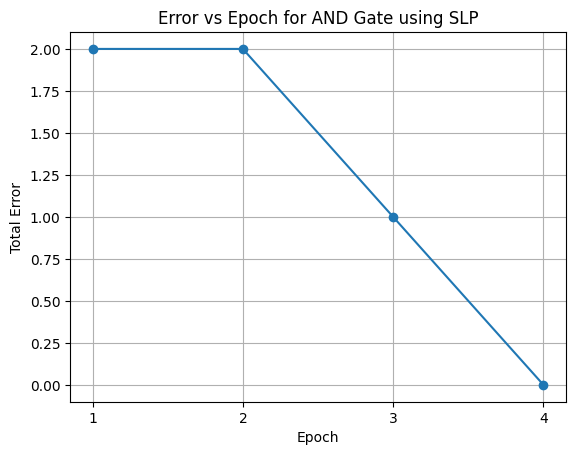

In [41]:
plt.plot(range(1, len(errors)+1), errors, marker='o')  # start epochs from 

plt.xlabel("Epoch")
plt.ylabel("Total Error")
plt.title("Error vs Epoch for AND Gate using SLP")

plt.xticks(range(1, len(errors)+1))  # show only integer epoch values
plt.grid(True)

plt.show()